# **Non-Stationary Spectral Decomposition Network (NS-SDN) For Econometric Forecasting**

Nikhil Sunder \
Student | ICSRI Research Fellow | Open-Source Developer \
B.S.B.A. Quantitative Economics, Finance & Minor in Math \
University of Miami Herbert Business School \
email: nss106@miami.edu \
phone: (305) 409-3108 \
links: [Github](https://github.com/nikhilxsunder) | [PyPI](https://pypi.org/user/nikhil.sunder/) | [Anaconda](https://anaconda.org/nikhil.sunder/) | [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) |
[ORCID](https://orcid.org/0009-0007-3323-1760) | [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22) | [Handshake](https://miami.joinhandshake.com/profiles/6pcqp4)

# NS-SDN: Testing & Validation

## Scope of this notebook

This notebook is a validation notebook, not a benchmark notebook. Its purpose is to verify that the NS-SDN implementation behaves correctly on real data before moving to formal experiments and application notebooks.

The goals here are:

1. confirm that the model trains stably on a real time series,
2. verify that loss declines under the current optimization setup,
3. inspect in-sample and holdout behavior,
4. distinguish conditional 1-step forecasting from fully recursive forecasting,
5. examine squared errors and internal spectral components,
6. perform a lightweight overfitting check using a validation split.

Formal benchmark comparisons against ARIMA, VAR, MLP, LSTM, and related models are deferred to the experiments notebook.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import fedfred as fd

DEVICE = (
    torch.device("cpu")
)

torch.manual_seed(1337)
np.random.seed(1337)

print("DEVICE:", DEVICE)

DEVICE: cpu


In [2]:
%run design.ipynb

In [3]:
fred=fd.FredAPI(api_key="7ab121fb17773e187bb6508e83e411da")

In [4]:
SERIES_ID = "DGS10"
START_DATE = "2000-02-01"
H = 365  # holdout horizon

df = fred.get_series_observations(series_id=SERIES_ID, observation_start=START_DATE, units="log")

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["value"])

# daily grid; fill short gaps only
df = df.asfreq("D")
df["value"] = df["value"].ffill(limit=7)
df = df.dropna(subset=["value"])

dates_all = df.index.to_numpy()
y_all_np = df["value"].to_numpy(dtype=np.float32).reshape(-1, 1)  # log(price)

print("N:", len(df))
df.head()

N: 9551


,realtime_start,realtime_end,value
date,,,
2000-02-01,2026-03-27,2026-03-27,1.89010
2000-02-02,2026-03-27,2026-03-27,1.88707
2000-02-03,2026-03-27,2026-03-27,1.87026
2000-02-04,2026-03-27,2026-03-27,1.87641
2000-02-05,NaN,NaN,1.87641


In [5]:
# ---------- tensors ----------
y_all = torch.from_numpy(y_all_np).float()
t_all = make_time_grid(len(y_all), dt=1.0, start=0.0)

N = y_all.shape[0]
assert N > H + 1000, f"Not enough data. N={N}"

split = N - H

y_hist = y_all[:split]
y_fut  = y_all[split:]

t_hist = t_all[:split]
t_fut  = t_all[split:]

dates_hist = dates_all[:split]
dates_fut  = dates_all[split:]

print("Train:", y_hist.shape, "Holdout:", y_fut.shape)

Train: torch.Size([9186, 1]) Holdout: torch.Size([365, 1])


In [6]:
# ---------- scaling ----------
y_scaler = MapMinMax.fit(y_hist, target_min=-1.0, target_max=1.0)

y_hist_s = y_scaler.transform(y_hist)
y_fut_s  = y_scaler.transform(y_fut)

# full eval sequence for 1-step alignment
y_eval   = torch.cat([y_hist, y_fut], dim=0)
t_eval   = torch.cat([t_hist, t_fut], dim=0)
y_eval_s = y_scaler.transform(y_eval)

split_eval = y_hist.shape[0]

assert t_eval.shape[0] == y_eval_s.shape[0]

In [7]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)

    err = y_pred - y_true
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))

    denom = np.where(np.abs(y_true) < 1e-12, np.nan, y_true)
    mape = float(np.nanmean(np.abs(err / denom)) * 100.0)

    return {
        "rmse": rmse,
        "mae": mae,
        "mape_pct": mape,
    }


def history_to_frame(*histories: tuple[str, dict]) -> pd.DataFrame:
    rows = []
    for label, hist in histories:
        for step, loss in hist["loss"]:
            rows.append({"stage": label, "step": step, "loss": loss})
    return pd.DataFrame(rows)


def plot_loss_history(*histories: tuple[str, dict]) -> None:
    df_hist = history_to_frame(*histories)
    plt.figure(figsize=(10, 5))
    for stage, g in df_hist.groupby("stage"):
        plt.plot(g["step"], g["loss"], label=stage)
    plt.title("Training loss by stage")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Main real-data fit

We train the baseline NS-SDN configuration in two stages. The first stage obtains a stable initial fit; the second stage refines the solution at a lower learning rate with slightly stronger smoothness regularization.

This is not intended to be the final experimental tuning procedure. It is a practical validation pass to confirm that the architecture learns a usable representation on a real series.

In [8]:
model = NSSDNStateSpace(
    y_dim=1,
    x_dim=0,
    h_dim=128,
    k=16,
    transition="gru",
    positive_omega=True,
    use_gating=True,
).to(DEVICE)

print("Trainable params:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable params: 58849


In [9]:
batch_tr = TimeSeriesBatch(t=t_hist, y=y_hist, x=None)

res_a = train_state_space_nssdn(
    model=model,
    batch=batch_tr,
    y_scaler=y_scaler,
    lr=1e-3,
    steps=1200,
    teacher_forcing=True,
    use_nll=False,
    lam_A=2e-4,
    lam_omega=8e-4,
    lam_theta2=0.0,
    lam_psd=0.0,
    device=DEVICE,
)

model = res_a["model"]

In [10]:
res_b = train_state_space_nssdn(
    model=model,
    batch=batch_tr,
    y_scaler=y_scaler,
    lr=4e-4,
    steps=1800,
    teacher_forcing=True,
    use_nll=False,
    lam_A=3e-4,
    lam_omega=1.5e-3,
    lam_theta2=0.0,
    lam_psd=0.0,
    device=DEVICE,
)

model = res_b["model"]

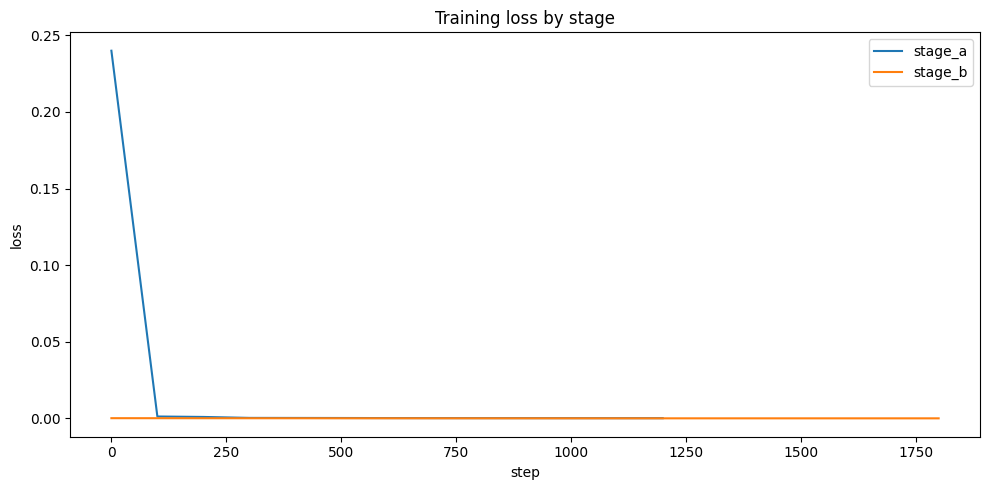

In [11]:
plot_loss_history(
    ("stage_a", res_a["history"]),
    ("stage_b", res_b["history"]),
)

## In-sample diagnostic

Before evaluating holdout behavior, we verify that the trained model can reproduce the historical segment under teacher forcing. This is a fit diagnostic only; it is not an out-of-sample evaluation.

In [12]:
with torch.no_grad():
    out_hist = model.forward_sequence(
        t_hist.to(DEVICE),
        y_hist_s.to(DEVICE),
        teacher_forcing=True,
    )

yhat_hist_s = out_hist["yhat"].detach().cpu()
hist_fit_lp = y_scaler.inverse_transform(yhat_hist_s).numpy().squeeze()
hist_true_lp = y_hist.numpy().squeeze()

hist_fit_p = np.exp(hist_fit_lp)
hist_true_p = np.exp(hist_true_lp)

train_metrics_log = compute_metrics(hist_true_lp, hist_fit_lp)
train_metrics_price = compute_metrics(hist_true_p, hist_fit_p)

pd.DataFrame(
    [train_metrics_log, train_metrics_price],
    index=["train_log_scale", "train_price_scale"],
)

,rmse,mae,mape_pct
train_log_scale,0.000848,0.000561,0.095320
train_price_scale,0.002322,0.001646,0.056083


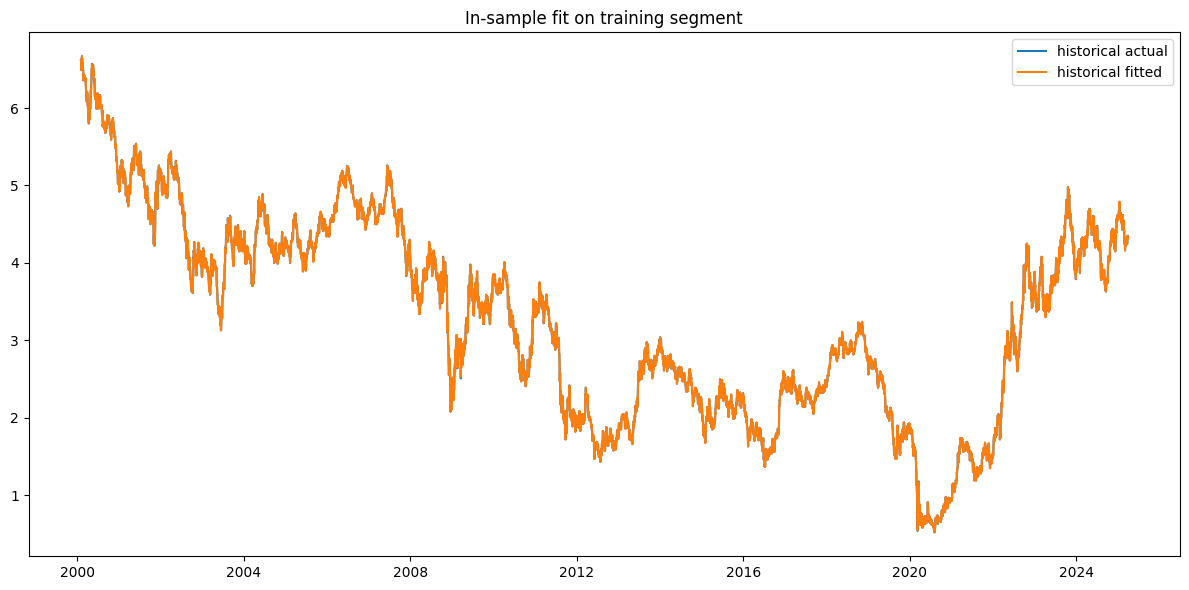

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(dates_hist, hist_true_p, label="historical actual")
plt.plot(dates_hist, hist_fit_p, label="historical fitted")
plt.title("In-sample fit on training segment")
plt.legend()
plt.tight_layout()
plt.show()

## Conditional 1-step holdout evaluation

The next section evaluates conditional one-step-ahead forecasts over the holdout window. At each step, the model advances using the realized observation from the previous step. This is therefore a rolling conditional forecast path, not a pure recursive multi-step forecast.

In [14]:
with torch.no_grad():
    out = model.forward_sequence(
        t_eval.to(DEVICE),
        y_eval_s.to(DEVICE),
        teacher_forcing=True
    )

yhat_eval_s = out["yhat"].detach().cpu()

# 1-step ahead over holdout
yhat_1step_s = yhat_eval_s[split_eval-1:-1]
ytrue_hold_s = y_eval_s[split_eval:]

assert yhat_1step_s.shape == ytrue_hold_s.shape

In [15]:
# inverse scaling (still log-price)
hist_lp = y_scaler.inverse_transform(y_eval_s[:split_eval]).numpy().squeeze()
fut_lp  = y_scaler.inverse_transform(ytrue_hold_s).numpy().squeeze()
one_lp  = y_scaler.inverse_transform(yhat_1step_s).numpy().squeeze()

# convert log-price to price
hist_p = np.exp(hist_lp)
fut_p  = np.exp(fut_lp)
one_p  = np.exp(one_lp)

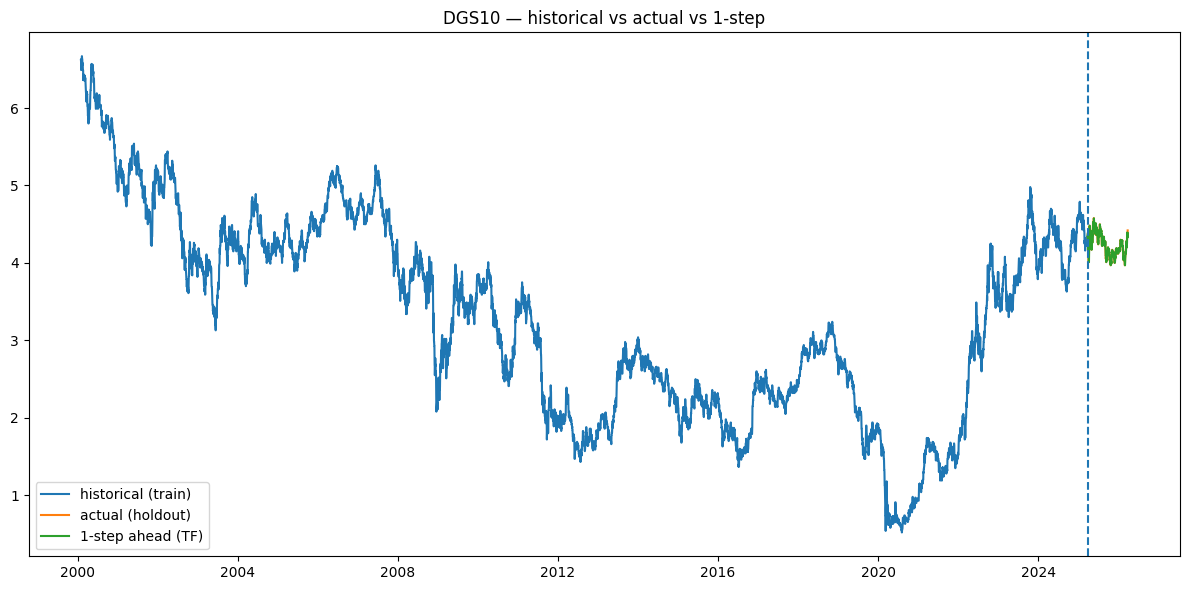

In [52]:
plt.figure(figsize=(12,6))
plt.plot(dates_hist, hist_p, label="historical (train)")
plt.plot(dates_fut,  fut_p,  label="actual (holdout)")
plt.plot(dates_fut,  one_p,  label="1-step ahead (TF)")
plt.axvline(dates_fut[0], linestyle="--")
plt.title("DGS10 — historical vs actual vs 1-step")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
metrics_scaled = compute_metrics(
    ytrue_hold_s.numpy().squeeze(),
    yhat_1step_s.numpy().squeeze(),
)

metrics_log = compute_metrics(fut_lp, one_lp)
metrics_price = compute_metrics(fut_p, one_p)

metrics_df = pd.DataFrame(
    [metrics_scaled, metrics_log, metrics_price],
    index=["holdout_1step_scaled", "holdout_1step_log", "holdout_1step_price"],
)
metrics_df

,rmse,mae,mape_pct
holdout_1step_scaled,0.007125,0.004780,0.741688
holdout_1step_log,0.009090,0.006099,0.422130
holdout_1step_price,0.038700,0.025893,0.609786


## Conditional 1-step error diagnostics

Scalar summary metrics can hide localized failure. We therefore inspect the squared forecast error through time across the holdout window.

In [18]:
se_1step = (one_p - fut_p) ** 2
ae_1step = np.abs(one_p - fut_p)

err_df = pd.DataFrame(
    {
        "date": pd.to_datetime(dates_fut),
        "actual_price": fut_p,
        "pred_price_1step": one_p,
        "squared_error_1step": se_1step,
        "abs_error_1step": ae_1step,
    }
)

err_df.head()

,date,actual_price,pred_price_1step,squared_error_1step,abs_error_1step
0,2025-03-27,4.380006,4.347642,0.001047,0.032364
1,2025-03-28,4.269984,4.379673,0.012032,0.109688
2,2025-03-29,4.269984,4.275506,0.000030,0.005522
3,2025-03-30,4.269984,4.268644,0.000002,0.001340
4,2025-03-31,4.229991,4.270205,0.001617,0.040214


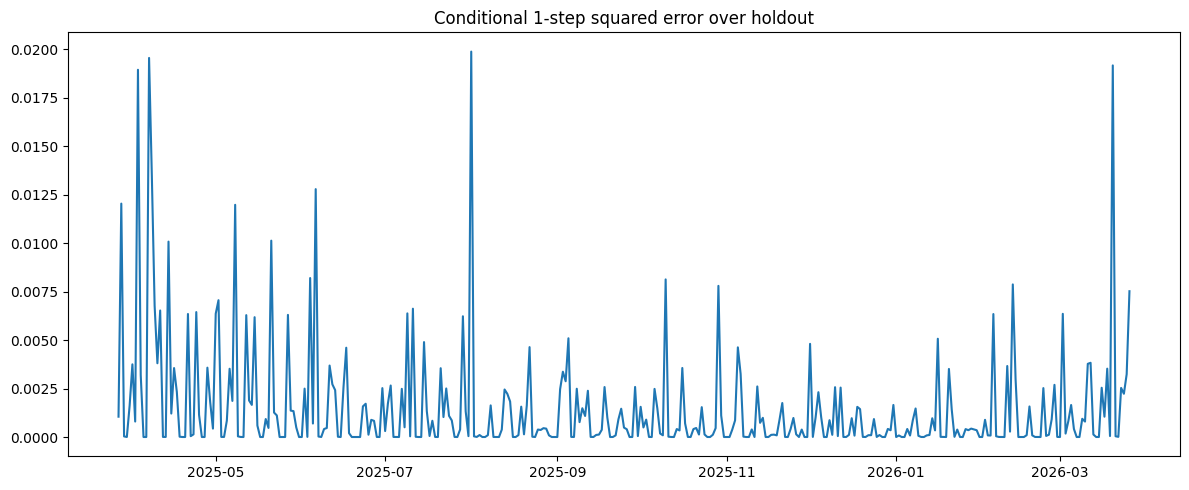

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(err_df["date"], err_df["squared_error_1step"])
plt.title("Conditional 1-step squared error over holdout")
plt.tight_layout()
plt.show()

In [20]:
def recursive_forecast_from_history(
    model: NSSDNStateSpace,
    t_hist: torch.Tensor,
    y_hist_s: torch.Tensor,
    t_fut: torch.Tensor,
    device: torch.device,
) -> torch.Tensor:
    model.eval()

    t_hist = ensure_2d(t_hist.to(device), "t_hist")
    y_hist_s = ensure_2d(y_hist_s.to(device), "y_hist_s")
    t_fut = ensure_2d(t_fut.to(device), "t_fut")

    with torch.no_grad():
        h_prev = model.h0.view(1, -1).to(device)
        theta_prev = model.theta0.view(1, -1).to(device)

        for n in range(t_hist.shape[0]):
            if n == 0:
                dt_n = torch.zeros(1, 1, device=device, dtype=t_hist.dtype)
            else:
                dt_n = t_hist[n:n+1] - t_hist[n-1:n]

            y_in = y_hist_s[n:n+1]
            x_in = y_in

            h_n = model.trans(h_prev, x_in, dt_n)
            params = model.emit(h_n)
            theta_n = theta_prev + params["omega"] * dt_n

            h_prev = h_n
            theta_prev = theta_n
            y_prev = y_in

        preds = []
        for n in range(t_fut.shape[0]):
            if n == 0:
                dt_n = t_fut[n:n+1] - t_hist[-1:]
            else:
                dt_n = t_fut[n:n+1] - t_fut[n-1:n]

            x_in = y_prev
            h_n = model.trans(h_prev, x_in, dt_n)
            params = model.emit(h_n)
            theta_n = theta_prev + params["omega"] * dt_n

            s = torch.sin(theta_n + params["phi"])
            osc = model.mix(params["A"] * s)
            y_n = params["B"] + osc

            preds.append(y_n.detach().cpu())

            h_prev = h_n
            theta_prev = theta_n
            y_prev = y_n

    return torch.cat(preds, dim=0)

## Fully recursive holdout forecast

We now generate a true multi-step holdout forecast. The model is warmed up on the historical segment, and the entire holdout horizon is then forecast recursively without feeding future realized values back into the state update. This is the stricter forecasting test.

In [21]:
yhat_rec_s = recursive_forecast_from_history(
    model=model,
    t_hist=t_hist,
    y_hist_s=y_hist_s,
    t_fut=t_fut,
    device=DEVICE,
)

rec_lp = y_scaler.inverse_transform(yhat_rec_s).numpy().squeeze()
rec_p = np.exp(rec_lp)

metrics_recursive_log = compute_metrics(fut_lp, rec_lp)
metrics_recursive_price = compute_metrics(fut_p, rec_p)

pd.DataFrame(
    [metrics_recursive_log, metrics_recursive_price],
    index=["holdout_recursive_log", "holdout_recursive_price"],
)

,rmse,mae,mape_pct
holdout_recursive_log,0.044584,0.037392,2.628756
holdout_recursive_price,0.188497,0.158983,3.830856


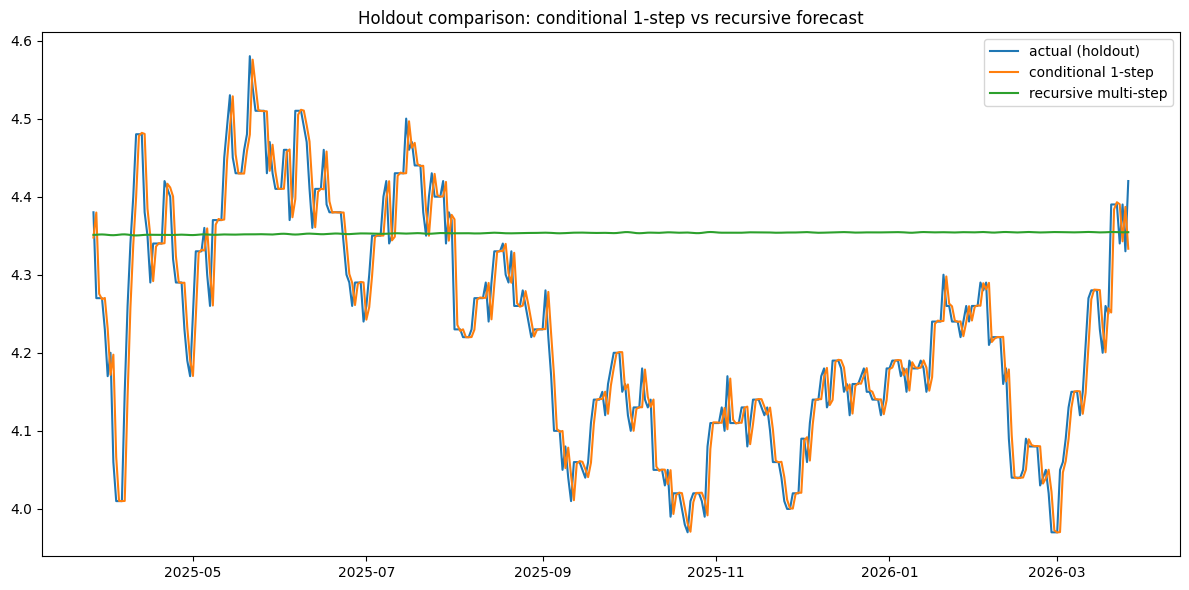

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(dates_fut, fut_p, label="actual (holdout)")
plt.plot(dates_fut, one_p, label="conditional 1-step")
plt.plot(dates_fut, rec_p, label="recursive multi-step")
plt.title("Holdout comparison: conditional 1-step vs recursive forecast")
plt.legend()
plt.tight_layout()
plt.show()

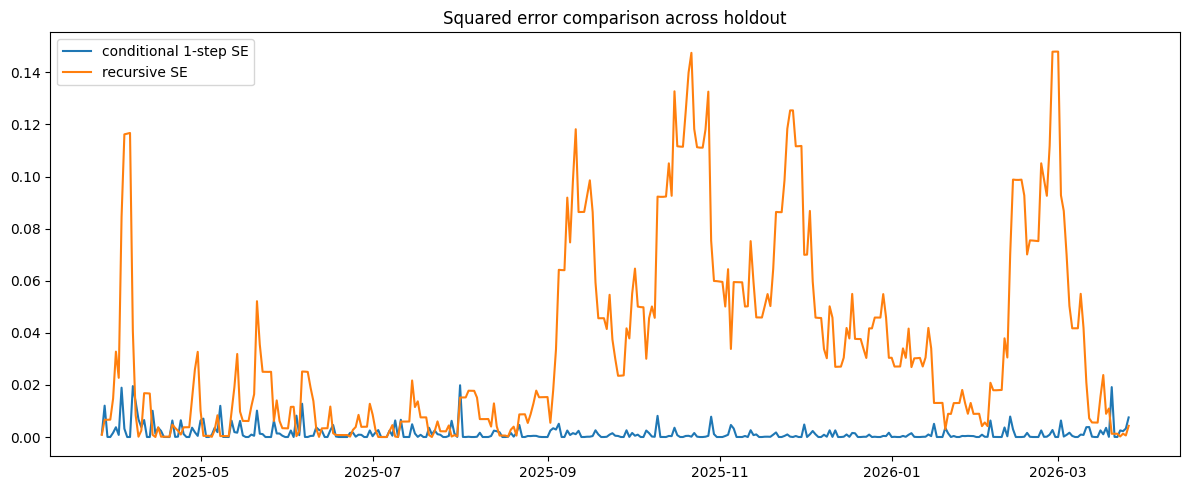

In [23]:
se_rec = (rec_p - fut_p) ** 2

plt.figure(figsize=(12, 5))
plt.plot(dates_fut, se_1step, label="conditional 1-step SE")
plt.plot(dates_fut, se_rec, label="recursive SE")
plt.title("Squared error comparison across holdout")
plt.legend()
plt.tight_layout()
plt.show()

## Internal component diagnostics

The NS-SDN architecture is intended to produce interpretable internal objects rather than only point forecasts. We therefore inspect the learned trend, amplitudes, frequencies, and gating behavior on the full evaluation sequence.

In [24]:
with torch.no_grad():
    out_eval = model.forward_sequence(
        t_eval.to(DEVICE),
        y_eval_s.to(DEVICE),
        teacher_forcing=True,
    )

B_eval = out_eval["B"].detach().cpu().numpy().squeeze()
A_eval = out_eval["A"].detach().cpu().numpy()
omega_eval = out_eval["omega"].detach().cpu().numpy()
theta_eval = out_eval["theta"].detach().cpu().numpy()

gate_eval = None
if "gate" in out_eval:
    gate_eval = out_eval["gate"].detach().cpu().numpy()

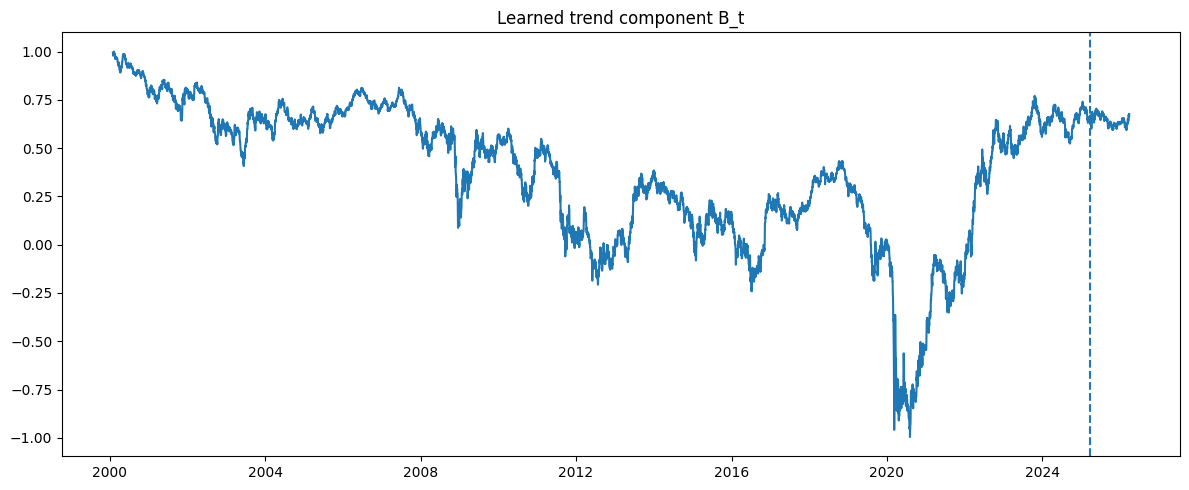

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(dates_all, B_eval)
plt.axvline(dates_fut[0], linestyle="--")
plt.title("Learned trend component B_t")
plt.tight_layout()
plt.show()

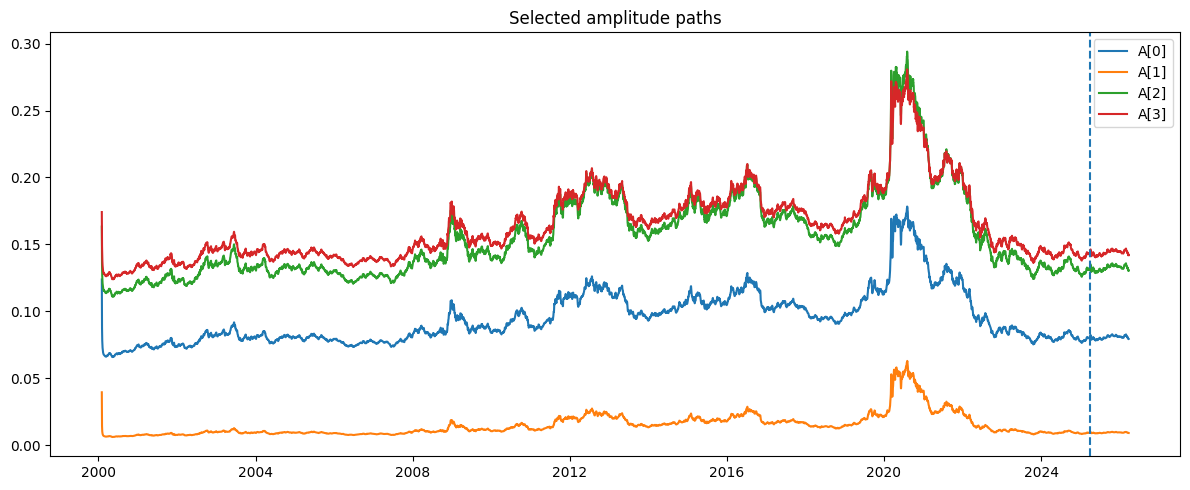

In [26]:
plt.figure(figsize=(12, 5))
for k_idx in range(min(4, A_eval.shape[1])):
    plt.plot(dates_all, A_eval[:, k_idx], label=f"A[{k_idx}]")
plt.axvline(dates_fut[0], linestyle="--")
plt.title("Selected amplitude paths")
plt.legend()
plt.tight_layout()
plt.show()

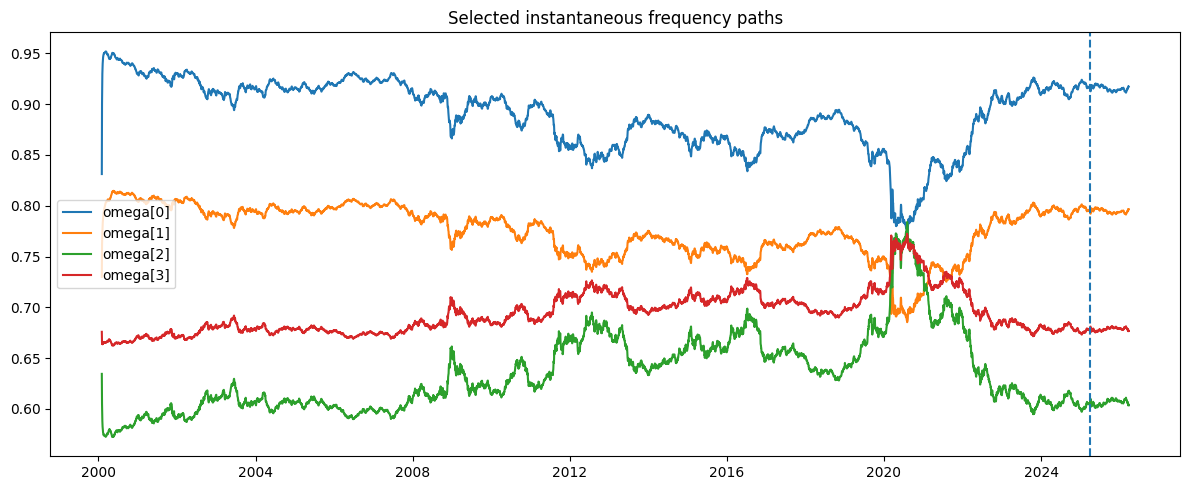

In [27]:
plt.figure(figsize=(12, 5))
for k_idx in range(min(4, omega_eval.shape[1])):
    plt.plot(dates_all, omega_eval[:, k_idx], label=f"omega[{k_idx}]")
plt.axvline(dates_fut[0], linestyle="--")
plt.title("Selected instantaneous frequency paths")
plt.legend()
plt.tight_layout()
plt.show()

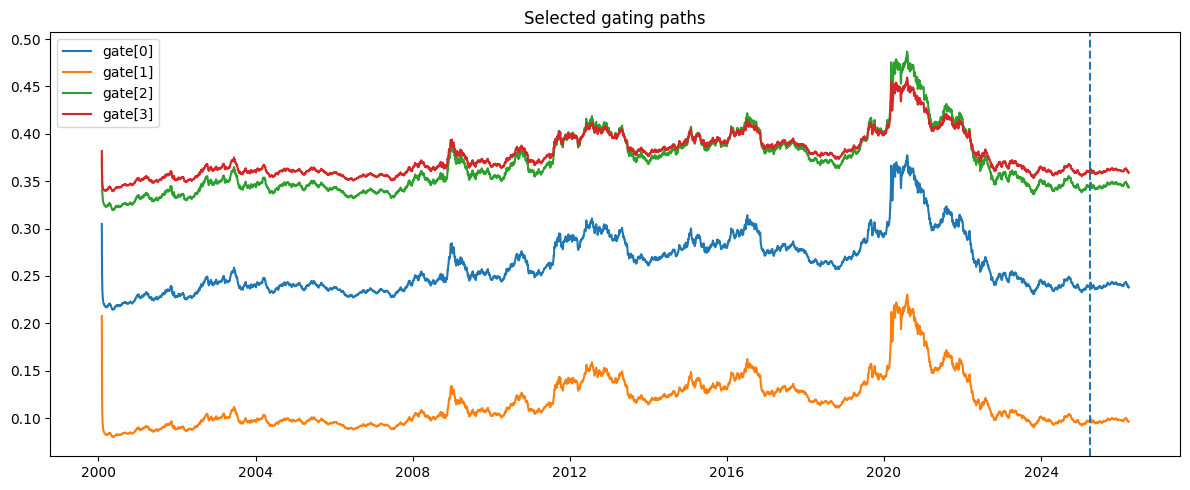

In [28]:
if gate_eval is not None:
    plt.figure(figsize=(12, 5))
    for k_idx in range(min(4, gate_eval.shape[1])):
        plt.plot(dates_all, gate_eval[:, k_idx], label=f"gate[{k_idx}]")
    plt.axvline(dates_fut[0], linestyle="--")
    plt.title("Selected gating paths")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Interpretation

If validation performance is only moderately worse than fit performance, then the current NS-SDN configuration is not obviously memorizing the historical segment. That would support moving to the experiments notebook for formal benchmark comparisons.

If the validation error is dramatically worse than the fit error, then the current configuration is likely too flexible for the series or too dependent on local training structure. In that case, the experiments notebook should include stronger regularization, smaller model capacity, alternative targets such as returns or differences, or a more robust recursive-training procedure.

In [29]:
import copy

recursive_model = copy.deepcopy(model).to(DEVICE)

In [30]:
res_rec_a = train_state_space_nssdn(
    model=recursive_model,
    batch=batch_tr,
    y_scaler=y_scaler,
    lr=2e-4,
    steps=1500,
    teacher_forcing=False,
    use_nll=False,
    lam_A=6e-4,
    lam_omega=2.0e-3,
    lam_theta2=0.0,
    lam_psd=0.0,
    device=DEVICE,
)

recursive_model = res_rec_a["model"]

In [31]:
res_rec_b = train_state_space_nssdn(
    model=recursive_model,
    batch=batch_tr,
    y_scaler=y_scaler,
    lr=1e-4,
    steps=1500,
    teacher_forcing=False,
    use_nll=False,
    lam_A=8e-4,
    lam_omega=2.5e-3,
    lam_theta2=0.0,
    lam_psd=0.0,
    device=DEVICE,
)

recursive_model = res_rec_b["model"]

### Loss history under recursive fine-tuning

Because free-running optimization is stricter than teacher-forced optimization, we inspect the loss history separately. A stable decline here would indicate that the model can continue adapting even when it is forced to consume its own predicted values rather than realized observations.

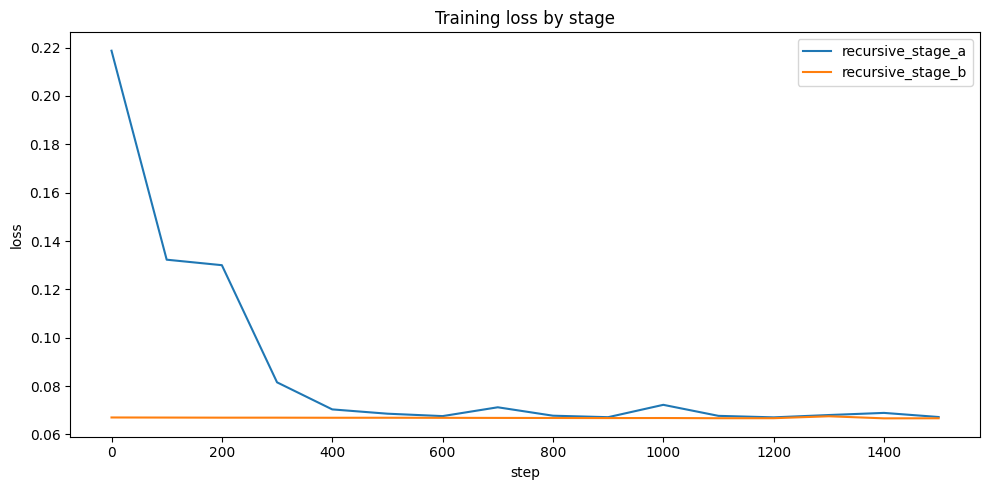

In [32]:
plot_loss_history(
    ("recursive_stage_a", res_rec_a["history"]),
    ("recursive_stage_b", res_rec_b["history"]),
)

### Recursive forecast after free-running fine-tuning

We now evaluate the fine-tuned model using the same strict recursive holdout procedure as before. This permits a direct comparison between:

1. the original teacher-forced baseline evaluated recursively, and
2. the recursively fine-tuned model evaluated recursively.

If the fine-tuned model exhibits less drift and preserves more local structure, then the earlier recursive failure is best interpreted as an exposure-bias problem induced by the teacher-forced training regime.

In [33]:
yhat_rec_ft_s = recursive_forecast_from_history(
    model=recursive_model,
    t_hist=t_hist,
    y_hist_s=y_hist_s,
    t_fut=t_fut,
    device=DEVICE,
)

rec_ft_lp = y_scaler.inverse_transform(yhat_rec_ft_s).numpy().squeeze()
rec_ft_p = np.exp(rec_ft_lp)

In [34]:
metrics_recursive_ft_log = compute_metrics(fut_lp, rec_ft_lp)
metrics_recursive_ft_price = compute_metrics(fut_p, rec_ft_p)

pd.DataFrame(
    [metrics_recursive_ft_log, metrics_recursive_ft_price],
    index=["holdout_recursive_finetuned_log", "holdout_recursive_finetuned_price"],
)

,rmse,mae,mape_pct
holdout_recursive_finetuned_log,0.502979,0.494825,34.343116
holdout_recursive_finetuned_price,1.662161,1.639451,38.760482


### Comparison of forecasting regimes

The figure below compares four distinct forecast objects:

1. the actual holdout path,
2. the conditional one-step forecast from the teacher-forced baseline,
3. the fully recursive forecast from the teacher-forced baseline, and
4. the fully recursive forecast from the recursively fine-tuned model.

The key question is whether free-running fine-tuning reduces long-horizon drift and preserves more of the local cyclical and level behavior of the holdout series.

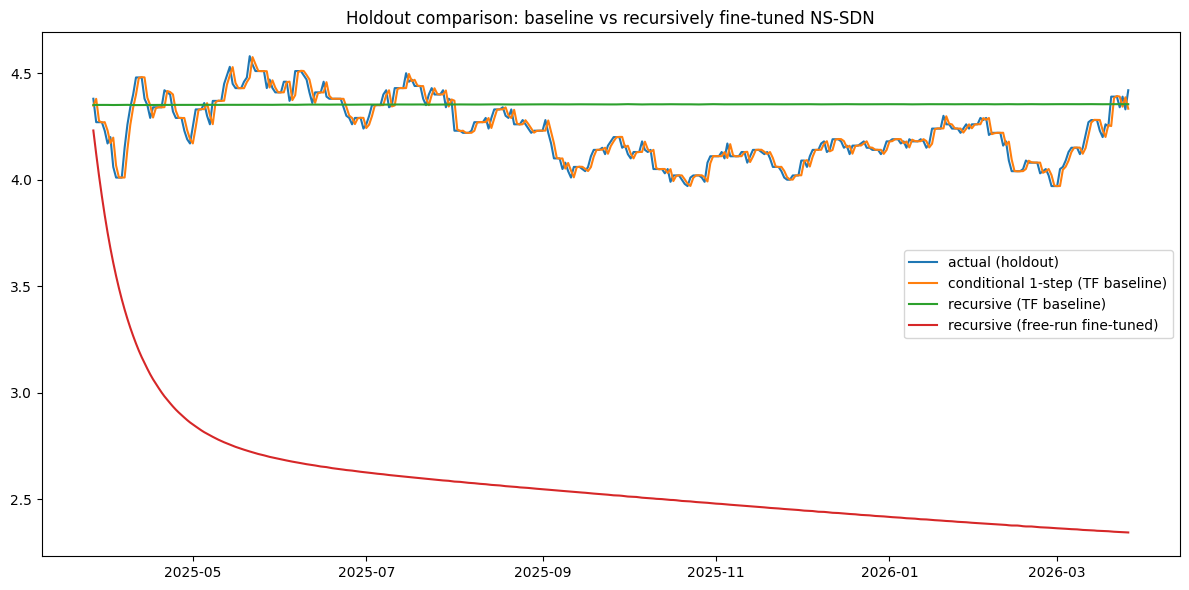

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(dates_fut, fut_p, label="actual (holdout)")
plt.plot(dates_fut, one_p, label="conditional 1-step (TF baseline)")
plt.plot(dates_fut, rec_p, label="recursive (TF baseline)")
plt.plot(dates_fut, rec_ft_p, label="recursive (free-run fine-tuned)")
plt.title("Holdout comparison: baseline vs recursively fine-tuned NS-SDN")
plt.legend()
plt.tight_layout()
plt.show()

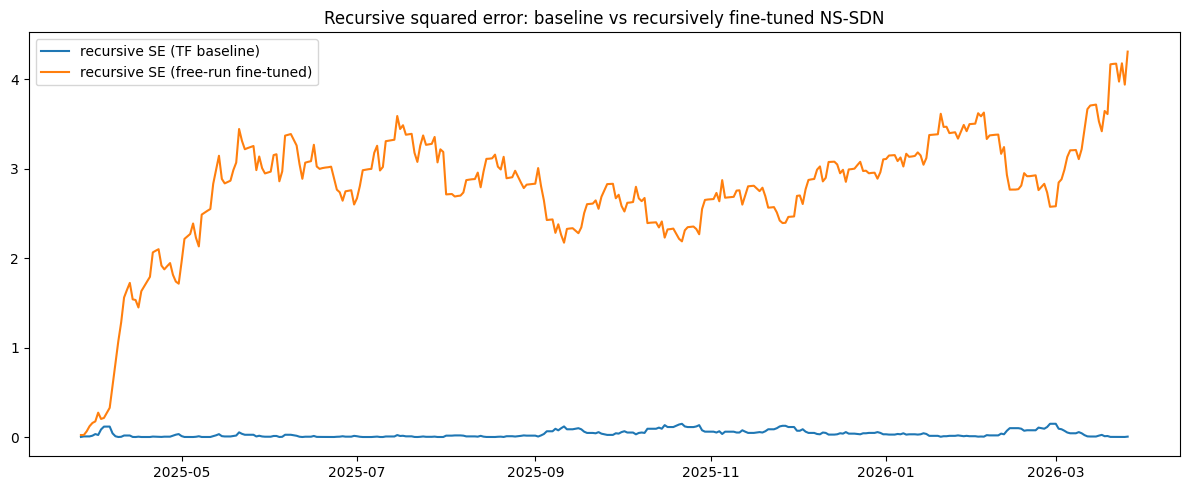

In [36]:
se_rec_ft = (rec_ft_p - fut_p) ** 2

plt.figure(figsize=(12, 5))
plt.plot(dates_fut, se_rec, label="recursive SE (TF baseline)")
plt.plot(dates_fut, se_rec_ft, label="recursive SE (free-run fine-tuned)")
plt.title("Recursive squared error: baseline vs recursively fine-tuned NS-SDN")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
comparison_df = pd.DataFrame(
    [
        compute_metrics(fut_p, one_p),
        compute_metrics(fut_p, rec_p),
        compute_metrics(fut_p, rec_ft_p),
    ],
    index=[
        "conditional_1step_tf_baseline",
        "recursive_tf_baseline",
        "recursive_finetuned",
    ],
)
comparison_df

,rmse,mae,mape_pct
conditional_1step_tf_baseline,0.038700,0.025893,0.609786
recursive_tf_baseline,0.188497,0.158983,3.830856
recursive_finetuned,1.662161,1.639451,38.760482


### Interpretation

If the recursively fine-tuned model improves materially over the original teacher-forced baseline in free-running mode, then the earlier recursive collapse is best interpreted as an exposure-bias problem. In that case, the architecture is capable of representing the series, but its transition dynamics must be trained under conditions that resemble recursive deployment.

If recursive performance improves only slightly, then the remaining error likely reflects a deeper modeling issue. The most plausible explanations are:

1. the price-level target is too nonstationary for stable free-running prediction,
2. the transition dynamics remain too contractive and collapse toward the trend component,
3. oscillator amplitudes decay too quickly during rollout, or
4. the current objective still prioritizes local fit more strongly than horizon stability.

Either outcome is informative for the experiments notebook, because it clarifies whether recursive weakness is primarily a training-regime issue or a broader architectural limitation.

## Lightweight overfitting check

To test whether the architecture is merely memorizing the training segment, we reserve the final portion of the historical sample as a validation block. A new NS-SDN model is then fit only on the earlier portion of the historical data, and its performance is compared on:

1. the reduced fit segment, and
2. the held-out validation segment.

This is not the final model-selection procedure. It is a diagnostic check intended to reveal whether the current configuration exhibits a large train–validation gap before moving to formal benchmark experiments.

In [38]:
VAL_FRAC = 0.10

n_train_full = y_hist.shape[0]
n_val = max(30, int(n_train_full * VAL_FRAC))
n_fit = n_train_full - n_val

if n_fit <= 0:
    raise ValueError("Validation split is too large for the available training history.")

y_fit = y_hist[:n_fit]
t_fit = t_hist[:n_fit]
dates_fit = dates_hist[:n_fit]

y_val = y_hist[n_fit:]
t_val = t_hist[n_fit:]
dates_val = dates_hist[n_fit:]

print("Full historical length:", n_train_full)
print("Fit segment length:", n_fit)
print("Validation segment length:", n_val)

Full historical length: 9186
Fit segment length: 8268
Validation segment length: 918


In [39]:
y_fit_scaler = MapMinMax.fit(y_fit, target_min=-1.0, target_max=1.0)

y_fit_s = y_fit_scaler.transform(y_fit)
y_val_s = y_fit_scaler.transform(y_val)

# combined fit + validation sequence for conditional 1-step alignment
y_fitval = torch.cat([y_fit, y_val], dim=0)
t_fitval = torch.cat([t_fit, t_val], dim=0)
y_fitval_s = y_fit_scaler.transform(y_fitval)

split_fitval = y_fit.shape[0]

assert t_fitval.shape[0] == y_fitval_s.shape[0]

### Separate validation-check model

A separate NS-SDN model is fit on the reduced fit segment only. This avoids contaminating the validation diagnostic with the full-sample training run used earlier in the notebook.

In [40]:
overfit_model = NSSDNStateSpace(
    y_dim=1,
    x_dim=0,
    h_dim=128,
    k=16,
    transition="gru",
    positive_omega=True,
    use_gating=True,
).to(DEVICE)

In [41]:
res_of_a = train_state_space_nssdn(
    model=overfit_model,
    batch=TimeSeriesBatch(t=t_fit, y=y_fit, x=None),
    y_scaler=y_fit_scaler,
    lr=1e-3,
    steps=1200,
    teacher_forcing=True,
    use_nll=False,
    lam_A=2e-4,
    lam_omega=8e-4,
    lam_theta2=0.0,
    lam_psd=0.0,
    device=DEVICE,
)

overfit_model = res_of_a["model"]

In [42]:
res_of_b = train_state_space_nssdn(
    model=overfit_model,
    batch=TimeSeriesBatch(t=t_fit, y=y_fit, x=None),
    y_scaler=y_fit_scaler,
    lr=4e-4,
    steps=1200,
    teacher_forcing=True,
    use_nll=False,
    lam_A=3e-4,
    lam_omega=1.5e-3,
    lam_theta2=0.0,
    lam_psd=0.0,
    device=DEVICE,
)

overfit_model = res_of_b["model"]

### Loss history for the validation-check model

We inspect the optimization path for the model trained on the reduced fit segment before comparing fit and validation behavior.

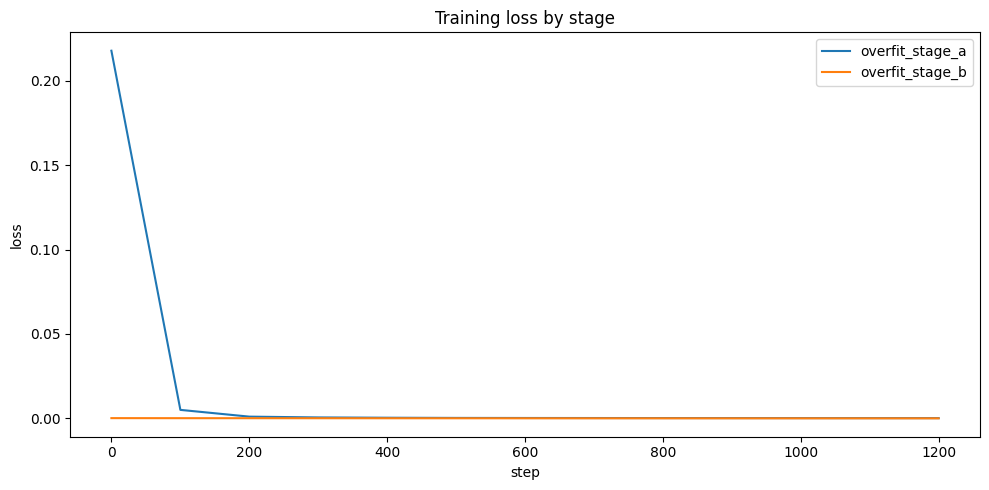

In [43]:
plot_loss_history(
    ("overfit_stage_a", res_of_a["history"]),
    ("overfit_stage_b", res_of_b["history"]),
)

In [44]:
with torch.no_grad():
    # in-sample fit on reduced fit segment
    out_fit = overfit_model.forward_sequence(
        t_fit.to(DEVICE),
        y_fit_s.to(DEVICE),
        teacher_forcing=True,
    )
    y_fit_hat_s = out_fit["yhat"].detach().cpu()

    # teacher-forced sequence over fit + validation for conditional 1-step validation alignment
    out_fitval = overfit_model.forward_sequence(
        t_fitval.to(DEVICE),
        y_fitval_s.to(DEVICE),
        teacher_forcing=True,
    )
    y_fitval_hat_s = out_fitval["yhat"].detach().cpu()

# conditional 1-step predictions for the validation block
y_val_hat_1step_s = y_fitval_hat_s[split_fitval - 1 : -1]
y_val_true_s = y_fitval_s[split_fitval:]

assert y_val_hat_1step_s.shape == y_val_true_s.shape
assert y_val_hat_1step_s.shape[0] == y_val.shape[0]

In [45]:
fit_lp_true = y_fit.numpy().squeeze()
fit_lp_pred = y_fit_scaler.inverse_transform(y_fit_hat_s).numpy().squeeze()

val_lp_true = y_val.numpy().squeeze()
val_lp_pred = y_fit_scaler.inverse_transform(y_val_hat_1step_s).numpy().squeeze()

fit_p_true = np.exp(fit_lp_true)
fit_p_pred = np.exp(fit_lp_pred)

val_p_true = np.exp(val_lp_true)
val_p_pred = np.exp(val_lp_pred)

In [46]:
overfit_metrics = pd.DataFrame(
    [
        compute_metrics(fit_lp_true, fit_lp_pred),
        compute_metrics(val_lp_true, val_lp_pred),
        compute_metrics(fit_p_true, fit_p_pred),
        compute_metrics(val_p_true, val_p_pred),
    ],
    index=[
        "fit_log",
        "validation_log",
        "fit_price",
        "validation_price",
    ],
)
overfit_metrics

,rmse,mae,mape_pct
fit_log,0.002192,0.001406,0.258671
validation_log,0.014277,0.009491,0.687204
fit_price,0.005557,0.003924,0.140585
validation_price,0.056849,0.038213,0.949605


### Visual comparison: fit segment vs validation segment

The next two figures compare the model's in-sample fit on the reduced fit segment and its conditional one-step behavior on the validation block. A moderate degradation from fit to validation is normal. A very large gap would suggest overfitting or excessive sensitivity to local training structure.

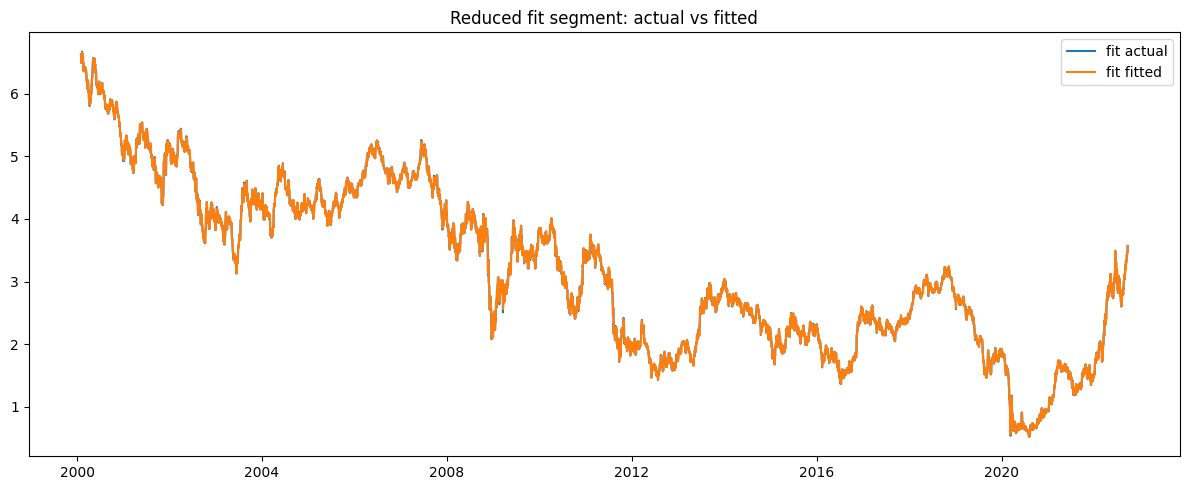

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(dates_fit, fit_p_true, label="fit actual")
plt.plot(dates_fit, fit_p_pred, label="fit fitted")
plt.title("Reduced fit segment: actual vs fitted")
plt.legend()
plt.tight_layout()
plt.show()

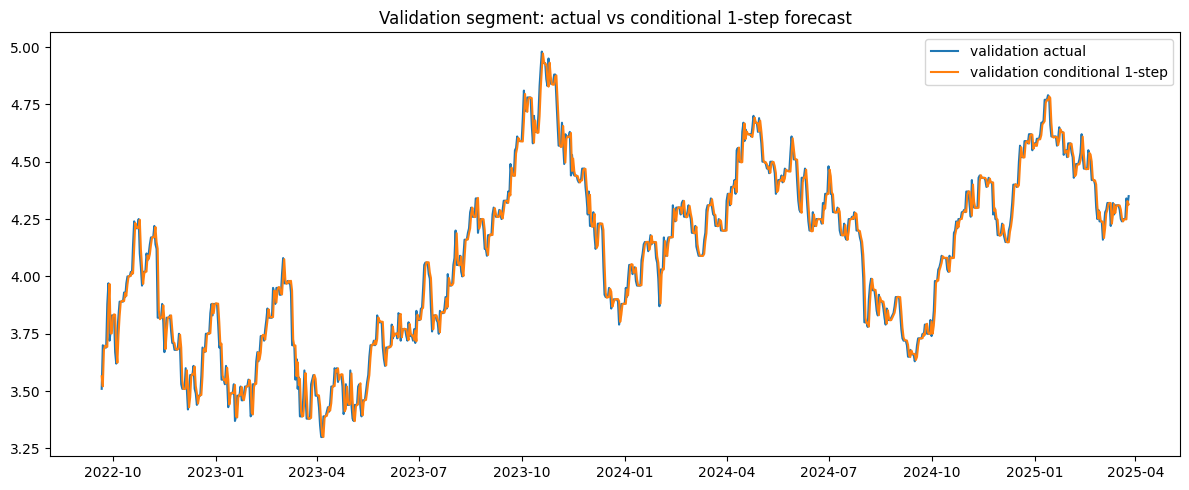

In [48]:
plt.figure(figsize=(12, 5))
plt.plot(dates_val, val_p_true, label="validation actual")
plt.plot(dates_val, val_p_pred, label="validation conditional 1-step")
plt.title("Validation segment: actual vs conditional 1-step forecast")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
gap_summary = pd.DataFrame(
    {
        "rmse_gap_price": [
            overfit_metrics.loc["validation_price", "rmse"]
            - overfit_metrics.loc["fit_price", "rmse"]
        ],
        "mae_gap_price": [
            overfit_metrics.loc["validation_price", "mae"]
            - overfit_metrics.loc["fit_price", "mae"]
        ],
        "mape_gap_price": [
            overfit_metrics.loc["validation_price", "mape_pct"]
            - overfit_metrics.loc["fit_price", "mape_pct"]
        ],
    },
    index=["validation_minus_fit"],
)
gap_summary

,rmse_gap_price,mae_gap_price,mape_gap_price
validation_minus_fit,0.051292,0.034289,0.80902


### Interpretation

If validation performance is only moderately worse than fit performance, then the current NS-SDN configuration is not obviously memorizing the historical segment. That would support moving to the experiments notebook for formal benchmark comparisons.

If the validation error is dramatically worse than the fit error, then the current configuration is likely too flexible for the series or too dependent on local training structure. In that case, the experiments notebook should include stronger regularization, smaller model capacity, alternative targets such as returns or differences, or a more robust recursive-training procedure.

## Conclusion

The tests in this notebook establish that the NS-SDN implementation:

1. trains stably on a real series,
2. produces a usable in-sample fit,
3. generates coherent conditional 1-step forecasts,
4. can also produce a fully recursive multi-step holdout forecast,
5. exposes interpretable internal component paths,
6. is suitable for formal benchmark comparison in the experiments notebook.

The next notebook should therefore focus on benchmark models, rolling-origin evaluation, horizon-specific metrics, and formal hypothesis testing.

In [50]:
checkpoint = {
    "series_id": SERIES_ID,
    "start_date": START_DATE,
    "holdout_horizon": H,
    "model_config": {
        "y_dim": 1,
        "x_dim": 0,
        "h_dim": 128,
        "k": 16,
        "transition": "gru",
        "positive_omega": True,
        "use_gating": True,
    },
    "state_dict": model.state_dict(),
    "scaler_y_x_min": y_scaler.feature_min.cpu(),
    "scaler_y_x_max": y_scaler.feature_max.cpu(),
    "scaler_y_target_min": y_scaler.target_min,
    "scaler_y_target_max": y_scaler.target_max,
    "stage_a_history": res_a["history"],
    "stage_b_history": res_b["history"],
}

torch.save(checkpoint, "nssdn_tests_checkpoint_cbethusd.pt")